In [24]:
# benchmark metric comparison
import pandas as pd
import seaborn as sn
from glob import glob
import pylab as plt
import numpy as np

import sys
sys.path.append('../')
import MHMDS.embed_funs as emb
import MHMDS.quality_metrics as qms

from scipy import stats

from scipy.optimize import minimize
import matplotlib.patches as mpatches

In [2]:
# plot parameters
plt.style.use('my_journal.mplstyle')
def clean_axis(ax=None):
    if ax is None:
        ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3)

In [ ]:
# for each pair, load embedding matrix and original feature matrix, and compute metrics
datasets = {'Paul':[20,100], 'Olsson':[20,100], 'Celegans_10k':[60,100]}
# prepare df to store results
# cols = ['Dataset', 'PCA_n1', 'PCA_n2', 'dimension', 'pair','Qglobal', 'Qlocal', 'corr']
# results = pd.DataFrame(columns=cols)
# for dset in datasets.keys():
#     for nd in [2,3]:
#         print('Processing dataset %s, dimension %i'%(dset,nd))
#         # load feature matrix
#         feat1 = np.loadtxt('../data/FeatMat_%s_PCA%i/FeatMat_%s_PCA%i.txt'%(dset, datasets[dset][0],dset, datasets[dset][0]))
#         feat2 = np.loadtxt('../data/FeatMat_%s_PCA%i/FeatMat_%s_PCA%i.txt'%(dset, datasets[dset][1],dset, datasets[dset][1]))
#         # dmats
#         dmat1 = emb.get_dmat_euc(feat1)
#         dmat2 = emb.get_dmat_euc(feat2)

#         nsample = len(feat1)
#         # load embedding matrix
#         pcoords1 = np.loadtxt(glob('../MultiscalehMDS_feature/PC_number_test/FeatMat_%s_PCA%i/*Nd_%i*%i.txt'%
#                             (dset, datasets[dset][0],nd,nsample))[0])
#         inds1 = np.loadtxt(glob('../MultiscalehMDS_feature/PC_number_test/FeatMat_%s_PCA%i/*Nd_%i*_inds*.txt'%
#                             (dset, datasets[dset][0],nd))[0])
#         pcoords1 = pcoords1[np.argsort(inds1)]
#         pcoords2 = np.loadtxt(glob('../MultiscalehMDS_feature/result/FeatMat_%s_PCA%i/benchmark/*Nd_%i*%i.txt'%
#                             (dset, datasets[dset][1],nd,nsample))[0])
#         inds2 = np.loadtxt(glob('../MultiscalehMDS_feature/result/FeatMat_%s_PCA%i/benchmark/*Nd_%i*_inds*.txt'%
#                             (dset, datasets[dset][1],nd))[0])
#         pcoords2 = pcoords2[np.argsort(inds2)]

#         # dmats of embedding
#         dmat1_poin = emb.get_dmat_poin(pcoords1)
#         dmat2_poin = emb.get_dmat_poin(pcoords2)
        
#         # compute quality metrics
#         pairs_to_compute = {'Between_Feature':(dmat1, dmat2), 
#                             'feat 1 - emb 1': (dmat1, dmat1_poin), 
#                             'feat 2 - emb 2': (dmat2, dmat2_poin),
#                             'feat 1 - emb 2': (dmat1, dmat2_poin),
#                             'feat 2 - emb 1': (dmat2, dmat1_poin)}
#         for pair in pairs_to_compute.keys():
#             print('  Computing pair %s...'%pair)
#             dmat_a, dmat_b = pairs_to_compute[pair]
#             qlocal, qglobal, _ = qms.get_quality_metrics(dmat_a,dmat_b)
#             corr = stats.pearsonr(dmat_a[np.triu_indices(nsample, k=1)],
#                         dmat_b[np.triu_indices(nsample, k=1)])[0]
#             new_row = {'Dataset':dset, 'PCA_n1':datasets[dset][0], 'PCA_n2':datasets[dset][1],
#                           'dimension':nd,
#                     'pair':pair, 'Qglobal':qglobal, 'Qlocal':qlocal, 'corr':corr}
#             results = pd.concat([results, pd.DataFrame([new_row])], ignore_index=True)
    

Processing dataset Celegans_10k, dimension 2
  Computing pair Between_Feature...
  Computing pair feat 1 - emb 1...
  Computing pair feat 2 - emb 2...
  Computing pair feat 1 - emb 2...
  Computing pair feat 2 - emb 1...
Processing dataset Celegans_10k, dimension 3
  Computing pair Between_Feature...
  Computing pair feat 1 - emb 1...
  Computing pair feat 2 - emb 2...
  Computing pair feat 1 - emb 2...
  Computing pair feat 2 - emb 1...


In [111]:
# rename column entries for better visualization
results = pd.read_csv('PC_number_test_metrics.csv')
replacedict = {'Between_Feature':'Input$_k$ ↔ Input$_{100}$',
                'feat 1 - emb 1':'Input$_k$ ↔ H$_k$',
                'feat 2 - emb 2':'Input$_{100}$ ↔ H$_{100}$',
                'feat 1 - emb 2':'Input$_k$ ↔ H$_{100}$',
                'feat 2 - emb 1':'Input$_{100}$ ↔ H$_k$'}
results['pair'] = results['pair'].replace(replacedict)
results.rename(columns={'corr':'Correlation'}, inplace=True)

/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_47404/1989848204.py:17: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[i].set_xticklabels(axs[i].get_xticklabels(), fontsize=12)
/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_47404/1989848204.py:18: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[i].set_yticklabels(axs[i].get_yticklabels(), fontsize=12)
/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_47404/1989848204.py:17: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[i].set_xticklabels(axs[i].get_xticklabels(), fontsize=12)
/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_47404/1989848204.py:18: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[i].set_yticklabels(axs[i].get_yticklabels(), fontsize=12)
/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_47404/1989848204.py:17: UserWarning: FixedFormatter s

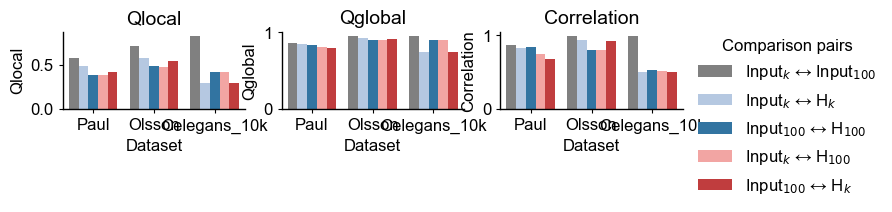

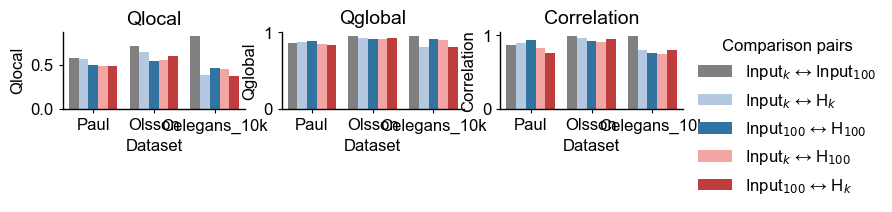

In [ ]:
# plot comparison barplots
for nd in [2,3]:
    fig,axs = plt.subplots(1,3,figsize=(12,2.5))
    axs = axs.flatten()
    metric_to_plot = ['Qlocal','Qglobal','Correlation']
    colormaps = dict(zip(replacedict.values(),
                         ['grey','#aec7e8','#1f77b4','#ff9896','#d62728']))
    for i, metric in enumerate(metric_to_plot):
        sn.barplot(data=results[results['dimension']==nd], x='Dataset', y=metric, hue='pair', ax=axs[i],
                palette=colormaps)
        axs[i].set_title(metric)
        axs[i].set_ylabel(metric, fontsize=12)
        axs[i].set_xlabel('Dataset', fontsize=12)
        axs[i].legend_.remove()
        axs[i].set_title(metric, fontsize=14)
        clean_axis(axs[i])
        axs[i].set_xticklabels(axs[i].get_xticklabels(), fontsize=12)
        axs[i].set_yticklabels(axs[i].get_yticklabels(), fontsize=12)
    axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., 
                  title='Comparison pairs', fontsize=12, title_fontsize=12)
    plt.tight_layout()
    plt.savefig('../../../summary_note/MHMDS_figures/supp/PC_number_test_metrics_comparison_nd%s.svg'%nd, format='svg', transparent=True)